# Traffic Sign Visual Question Answering

Pipeline chính cho đồ án VQA biển báo giao thông tiếng Việt.

Notebook này tập trung vào phần cần nộp/chạy lại: kiểm tra dataset, định nghĩa model, train A1/A2, evaluate, và ghi chú cho B1/B2 + Bài 2.


## 0. Setup

Khai báo thư viện, seed và đường dẫn project.


In [2]:
from pathlib import Path
import json
import math
import os
import random
from collections import Counter, defaultdict
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from PIL import Image

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGE_DIR = DATASET_DIR / "images"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)


Project root: d:\source\HK6\DeepLearning\final_vqa
Device: cuda


c:\Users\Dong Khoi Dev\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Colab + Google Drive setup.
# Nếu chạy trên Colab, sửa COLAB_PROJECT_ROOT cho đúng thư mục chứa source.ipynb/dataset/checkpoints.
USE_COLAB_DRIVE = False
COLAB_PROJECT_ROOT = "/content/drive/MyDrive/final_vqa"
SET_HF_CACHE_TO_DRIVE = False

# Nên bật cache local trên Colab: đọc ảnh từ Drive lâu và đôi khi lỗi
# "Transport endpoint is not connected" khi train/validation.
CACHE_DATASET_TO_LOCAL = True
FORCE_RECOPY_DATASET = False
LOCAL_RUNTIME_ROOT = Path("/content/final_vqa_runtime")

if USE_COLAB_DRIVE:
    from google.colab import drive
    import shutil

    drive.mount("/content/drive", force_remount=True)
    DRIVE_PROJECT_ROOT = Path(COLAB_PROJECT_ROOT)
    PROJECT_ROOT = DRIVE_PROJECT_ROOT

    CHECKPOINT_DIR = DRIVE_PROJECT_ROOT / "checkpoints"
    RESULT_DIR = DRIVE_PROJECT_ROOT / "results"
    HF_CACHE_DIR = DRIVE_PROJECT_ROOT / "hf_cache"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    if SET_HF_CACHE_TO_DRIVE:
        HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        os.environ["HF_HOME"] = str(HF_CACHE_DIR)
        os.environ["HF_HUB_CACHE"] = str(HF_CACHE_DIR / "hub")
        os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE_DIR / "transformers")
        print("Hugging Face cache is saved to Drive:", HF_CACHE_DIR)

    if CACHE_DATASET_TO_LOCAL:
        source_dataset = DRIVE_PROJECT_ROOT / "dataset"
        local_dataset = LOCAL_RUNTIME_ROOT / "dataset"
        if FORCE_RECOPY_DATASET and local_dataset.exists():
            shutil.rmtree(local_dataset)
        if not local_dataset.exists():
            LOCAL_RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
            print(f"Copying dataset to local runtime: {local_dataset}")
            shutil.copytree(source_dataset, local_dataset)
        DATASET_DIR = local_dataset
        IMAGE_DIR = DATASET_DIR / "images"
        print("Dataset is read from local runtime:", DATASET_DIR)
    else:
        DATASET_DIR = DRIVE_PROJECT_ROOT / "dataset"
        IMAGE_DIR = DATASET_DIR / "images"
        print("Dataset is read directly from Drive:", DATASET_DIR)

    print("Checkpoints/results are saved to Drive:", CHECKPOINT_DIR)
else:
    RESULT_DIR = PROJECT_ROOT / "results"
    RESULT_DIR.mkdir(parents=True, exist_ok=True)
    print("Using local project root:", PROJECT_ROOT)


Using local project root: d:\source\HK6\DeepLearning\final_vqa


## 1. Kiểm Tra Dataset

Dataset đã được tạo sẵn trong `dataset/` với 10 QA/ảnh. Cell này kiểm tra các yêu cầu chính: số mẫu train > 2000, không trùng ảnh giữa các split, không thiếu ảnh và câu trả lời không quá 10 từ.


In [5]:
import re
from collections import Counter


def load_json_split(name: str) -> List[Dict]:
    path = DATASET_DIR / f"{name}.json"
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text(encoding="utf-8"))


vqa_records = load_json_split("vqa_data")
train_records = load_json_split("train")
val_records = load_json_split("val")
test_records = load_json_split("test")

split_records = {
    "train": train_records,
    "val": val_records,
    "test": test_records,
}

for split_name, records in [("vqa_data", vqa_records), *split_records.items()]:
    image_counts = Counter(row["image"] for row in records)
    missing_images = sorted({img for img in image_counts if not (IMAGE_DIR / img).exists()})
    long_answers = [
        row for row in records
        if len(re.findall(r"\w+", str(row.get("answer", "")), flags=re.UNICODE)) > 10
    ]
    print(
        f"{split_name}: {len(records)} QA | {len(image_counts)} images | "
        f"QA/image min={min(image_counts.values())}, max={max(image_counts.values())}"
    )
    print(f"  missing_images={len(missing_images)} | answers>10_words={len(long_answers)}")

split_images = {name: {row["image"] for row in rows} for name, rows in split_records.items()}
print("Overlap train/val:", len(split_images["train"] & split_images["val"]))
print("Overlap train/test:", len(split_images["train"] & split_images["test"]))
print("Overlap val/test:", len(split_images["val"] & split_images["test"]))

assert len(train_records) > 2000, "Train split chưa đạt > 2000 QA."
assert not (split_images["train"] & split_images["val"])
assert not (split_images["train"] & split_images["test"])
assert not (split_images["val"] & split_images["test"])


vqa_data: 2580 QA | 258 images | QA/image min=10, max=10
  missing_images=0 | answers>10_words=15
train: 2060 QA | 206 images | QA/image min=10, max=10
  missing_images=0 | answers>10_words=12
val: 250 QA | 25 images | QA/image min=10, max=10
  missing_images=0 | answers>10_words=2
test: 270 QA | 27 images | QA/image min=10, max=10
  missing_images=0 | answers>10_words=1
Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0


## 2. Core Definitions

Vocabulary, dataset, SquarePad preprocessing, image encoder, text encoder, decoder LSTM/Transformer và wrapper `VQAModel`.


In [ ]:
import math
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple, Union

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet18_Weights, resnet18
from torchvision import transforms


class SquarePad:
    """Pad a PIL image to square without distorting the traffic sign shape."""
    def __init__(self, fill=(255, 255, 255)):
        self.fill = fill

    def __call__(self, image):
        width, height = image.size
        max_side = max(width, height)
        pad_left = (max_side - width) // 2
        pad_top = (max_side - height) // 2
        pad_right = max_side - width - pad_left
        pad_bottom = max_side - height - pad_top
        return transforms.functional.pad(image, (pad_left, pad_top, pad_right, pad_bottom), fill=self.fill)


PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"


def tokenize_vi(text: str) -> List[str]:
    text = text.lower().strip()
    tokens = re.findall(r"[\wÀ-ỹ]+|[^\w\s]", text, flags=re.UNICODE)
    return [tok for tok in tokens if tok.strip()]


class SimpleVocab:
    def __init__(self, token_to_id: Dict[str, int]):
        self.token_to_id = dict(token_to_id)
        self.id_to_token = {idx: token for token, idx in self.token_to_id.items()}
        self.pad_idx = self.token_to_id[PAD_TOKEN]
        self.bos_idx = self.token_to_id[BOS_TOKEN]
        self.eos_idx = self.token_to_id[EOS_TOKEN]
        self.unk_idx = self.token_to_id[UNK_TOKEN]

    @classmethod
    def build(
        cls,
        texts: Sequence[str],
        min_freq: int = 1,
        max_size: Optional[int] = None,
        extra_tokens: Sequence[str] = (),
    ) -> "SimpleVocab":
        counter = Counter()
        for text in texts:
            counter.update(tokenize_vi(text))

        token_to_id = {
            PAD_TOKEN: 0,
            BOS_TOKEN: 1,
            EOS_TOKEN: 2,
            UNK_TOKEN: 3,
        }
        for token in extra_tokens:
            if token not in token_to_id:
                token_to_id[token] = len(token_to_id)

        sorted_tokens = sorted(counter.items(), key=lambda item: (-item[1], item[0]))
        for token, freq in sorted_tokens:
            if freq < min_freq or token in token_to_id:
                continue
            if max_size is not None and len(token_to_id) >= max_size:
                break
            token_to_id[token] = len(token_to_id)
        return cls(token_to_id)

    def __len__(self) -> int:
        return len(self.token_to_id)

    def encode(self, text: str, add_bos: bool = True, add_eos: bool = True) -> List[int]:
        ids = []
        if add_bos:
            ids.append(self.bos_idx)
        ids.extend(self.token_to_id.get(token, self.unk_idx) for token in tokenize_vi(text))
        if add_eos:
            ids.append(self.eos_idx)
        return ids

    def decode(self, ids: Sequence[int], skip_special: bool = True) -> str:
        tokens: List[str] = []
        for idx in ids:
            token = self.id_to_token.get(int(idx), UNK_TOKEN)
            if token == EOS_TOKEN:
                break
            if skip_special and token in {PAD_TOKEN, BOS_TOKEN, EOS_TOKEN}:
                continue
            tokens.append(token)
        return " ".join(tokens).strip()


def pad_sequences(sequences: Sequence[Sequence[int]], pad_value: int) -> Tuple[torch.Tensor, torch.Tensor]:
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(sequences) else 0
    padded = torch.full((len(sequences), max_len), pad_value, dtype=torch.long)
    for row, seq in enumerate(sequences):
        if seq:
            padded[row, : len(seq)] = torch.tensor(seq, dtype=torch.long)
    return padded, lengths


class VQADataset(Dataset):
    def __init__(
        self,
        records: Sequence[Dict],
        image_root: Union[str, Path],
        question_vocab: SimpleVocab,
        answer_vocab: SimpleVocab,
        image_transform: Optional[nn.Module] = None,
        max_question_length: Optional[int] = None,
        max_answer_length: Optional[int] = None,
    ):
        self.records = list(records)
        self.image_root = Path(image_root)
        self.question_vocab = question_vocab
        self.answer_vocab = answer_vocab
        self.image_transform = image_transform or transforms.Compose([
            SquarePad(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
        self.max_question_length = max_question_length
        self.max_answer_length = max_answer_length

    def __len__(self) -> int:
        return len(self.records)

    def _truncate(self, ids: List[int], max_length: Optional[int]) -> List[int]:
        if max_length is None or len(ids) <= max_length:
            return ids
        return ids[:max_length]

    def __getitem__(self, idx: int) -> Dict:
        record = self.records[idx]
        image_path = self.image_root / record["image"]
        from PIL import Image

        image = Image.open(image_path).convert("RGB")
        image = self.image_transform(image)

        question_ids = self._truncate(self.question_vocab.encode(record["question"]), self.max_question_length)
        answer_ids = self._truncate(self.answer_vocab.encode(record["answer"]), self.max_answer_length)

        return {
            "image": image,
            "question_ids": question_ids,
            "answer_ids": answer_ids,
            "question_text": record["question"],
            "answer_text": record["answer"],
            "image_name": record["image"],
        }


def collate_vqa_batch(batch: Sequence[Dict], pad_idx: int) -> Dict[str, torch.Tensor]:
    images = torch.stack([item["image"] for item in batch], dim=0)
    question_ids, question_lengths = pad_sequences([item["question_ids"] for item in batch], pad_idx)
    answer_ids, answer_lengths = pad_sequences([item["answer_ids"] for item in batch], pad_idx)

    return {
        "images": images,
        "question_ids": question_ids,
        "question_lengths": question_lengths,
        "answer_ids": answer_ids,
        "answer_lengths": answer_lengths,
        "raw_questions": [item["question_text"] for item in batch],
        "raw_answers": [item["answer_text"] for item in batch],
        "image_names": [item["image_name"] for item in batch],
    }


def lengths_to_mask(lengths: torch.Tensor, max_len: Optional[int] = None) -> torch.Tensor:
    if max_len is None:
        max_len = int(lengths.max().item())
    range_tensor = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return range_tensor >= lengths.unsqueeze(1)


class ImageEncoder(nn.Module):
    def __init__(self, output_dim: int = 512, pretrained: bool = True, train_backbone: bool = False):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
        self.stem = nn.Sequential(*list(backbone.children())[:-2])
        self.region_proj = nn.Conv2d(512, output_dim, kernel_size=1)
        self.global_proj = nn.Linear(512, output_dim)
        self.output_dim = output_dim

        if not train_backbone:
            for param in self.stem.parameters():
                param.requires_grad = False

    def forward(self, images: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        feature_map = self.stem(images)
        region_map = self.region_proj(feature_map)
        region_features = region_map.flatten(2).transpose(1, 2)
        global_features = feature_map.mean(dim=(2, 3))
        global_features = self.global_proj(global_features)
        return region_features, global_features


class TextEncoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 256,
        hidden_dim: int = 512,
        num_layers: int = 1,
        dropout: float = 0.1,
        rnn_type: str = "lstm",
        bidirectional: bool = False,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        rnn_cls = nn.LSTM if rnn_type.lower() == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.output_dim = hidden_dim * (2 if bidirectional else 1)
        self.output_proj = nn.Linear(self.output_dim, self.output_dim)
        self.pad_idx = pad_idx
        self.bidirectional = bidirectional
        self.rnn_type = rnn_type.lower()

    def forward(self, token_ids: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        embedded = self.embedding(token_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_outputs, hidden = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=token_ids.size(1),
        )
        outputs = self.output_proj(outputs)

        if self.rnn_type == "lstm":
            hidden_state = hidden[0]
        else:
            hidden_state = hidden
        hidden_state = hidden_state.transpose(0, 1).reshape(token_ids.size(0), -1)
        hidden_state = self.output_proj(hidden_state)
        return outputs, hidden_state


class BahdanauAttention(nn.Module):
    def __init__(self, query_dim: int, memory_dim: int, attn_dim: int):
        super().__init__()
        self.query_proj = nn.Linear(query_dim, attn_dim)
        self.memory_proj = nn.Linear(memory_dim, attn_dim)
        self.score_proj = nn.Linear(attn_dim, 1)

    def forward(
        self,
        query: torch.Tensor,
        memory: torch.Tensor,
        memory_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        query_proj = self.query_proj(query).unsqueeze(1)
        memory_proj = self.memory_proj(memory)
        scores = self.score_proj(torch.tanh(query_proj + memory_proj)).squeeze(-1)
        if memory_mask is not None:
            scores = scores.masked_fill(memory_mask, torch.finfo(scores.dtype).min)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), memory).squeeze(1)
        return context, weights


class VQALSTMDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        hidden_dim: int = 512,
        embed_dim: int = 256,
        image_dim: int = 512,
        question_dim: int = 512,
        attn_dim: int = 256,
        pad_idx: int = 0,
        bos_idx: int = 1,
        eos_idx: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.memory_proj = nn.Linear(image_dim, hidden_dim)
        self.attention = BahdanauAttention(hidden_dim, hidden_dim, attn_dim)
        self.input_proj = nn.Linear(embed_dim + hidden_dim, hidden_dim)
        self.lstm_cell = nn.LSTMCell(hidden_dim, hidden_dim)
        self.output_proj = nn.Linear(hidden_dim, vocab_size)
        self.init_hidden = nn.Linear(image_dim + question_dim, hidden_dim)
        self.init_cell = nn.Linear(image_dim + question_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx

    def _build_memory(
        self,
        image_seq: torch.Tensor,
        question_seq: torch.Tensor,
        question_lengths: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, image_steps, _ = image_seq.shape
        question_mask = lengths_to_mask(question_lengths, question_seq.size(1))
        image_mask = torch.zeros((batch_size, image_steps), dtype=torch.bool, device=image_seq.device)
        memory = torch.cat([image_seq, question_seq], dim=1)
        memory = self.memory_proj(memory)
        memory_mask = torch.cat([image_mask, question_mask], dim=1)
        return memory, memory_mask

    def forward(
        self,
        image_seq: torch.Tensor,
        image_global: torch.Tensor,
        question_seq: torch.Tensor,
        question_hidden: torch.Tensor,
        question_lengths: torch.Tensor,
        answer_input: torch.Tensor,
    ) -> torch.Tensor:
        memory, memory_mask = self._build_memory(image_seq, question_seq, question_lengths)
        init_state = torch.cat([image_global, question_hidden], dim=-1)
        hidden = torch.tanh(self.init_hidden(init_state))
        cell = torch.tanh(self.init_cell(init_state))

        logits = []
        context = memory.mean(dim=1)
        for step in range(answer_input.size(1)):
            token_embed = self.token_embed(answer_input[:, step])
            decoder_input = self.input_proj(torch.cat([token_embed, context], dim=-1))
            hidden, cell = self.lstm_cell(self.dropout(decoder_input), (hidden, cell))
            context, _ = self.attention(hidden, memory, memory_mask)
            step_logits = self.output_proj(self.dropout(hidden))
            logits.append(step_logits.unsqueeze(1))
        return torch.cat(logits, dim=1)

    @torch.no_grad()
    def generate(
        self,
        image_seq: torch.Tensor,
        image_global: torch.Tensor,
        question_seq: torch.Tensor,
        question_hidden: torch.Tensor,
        question_lengths: torch.Tensor,
        max_length: int = 16,
    ) -> torch.Tensor:
        memory, memory_mask = self._build_memory(image_seq, question_seq, question_lengths)
        init_state = torch.cat([image_global, question_hidden], dim=-1)
        hidden = torch.tanh(self.init_hidden(init_state))
        cell = torch.tanh(self.init_cell(init_state))

        batch_size = image_seq.size(0)
        current_token = torch.full((batch_size,), self.bos_idx, dtype=torch.long, device=image_seq.device)
        outputs = []
        context = memory.mean(dim=1)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=image_seq.device)

        for _ in range(max_length):
            token_embed = self.token_embed(current_token)
            decoder_input = self.input_proj(torch.cat([token_embed, context], dim=-1))
            hidden, cell = self.lstm_cell(self.dropout(decoder_input), (hidden, cell))
            context, _ = self.attention(hidden, memory, memory_mask)
            step_logits = self.output_proj(hidden)
            next_token = step_logits.argmax(dim=-1)
            outputs.append(next_token.unsqueeze(1))
            finished = finished | (next_token == self.eos_idx)
            current_token = next_token
            if finished.all():
                break
        if outputs:
            return torch.cat(outputs, dim=1)
        return torch.empty((batch_size, 0), dtype=torch.long, device=image_seq.device)


class VQATransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 512,
        num_heads: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_length: int = 32,
        pad_idx: int = 0,
        bos_idx: int = 1,
        eos_idx: int = 2,
        image_dim: int = 512,
        question_dim: int = 512,
    ):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embed = nn.Embedding(max_length, d_model)
        self.memory_proj = nn.Linear(image_dim, d_model)
        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, vocab_size)
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.max_length = max_length

    def _build_memory(
        self,
        image_seq: torch.Tensor,
        question_seq: torch.Tensor,
        question_lengths: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, image_steps, _ = image_seq.shape
        question_mask = lengths_to_mask(question_lengths, question_seq.size(1))
        image_mask = torch.zeros((batch_size, image_steps), dtype=torch.bool, device=image_seq.device)
        memory = torch.cat([image_seq, question_seq], dim=1)
        memory = self.memory_proj(memory)
        memory_mask = torch.cat([image_mask, question_mask], dim=1)
        return memory, memory_mask

    def _build_causal_mask(self, length: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones(length, length, device=device, dtype=torch.bool), diagonal=1)

    def forward(
        self,
        image_seq: torch.Tensor,
        image_global: torch.Tensor,
        question_seq: torch.Tensor,
        question_hidden: torch.Tensor,
        question_lengths: torch.Tensor,
        answer_input: torch.Tensor,
    ) -> torch.Tensor:
        memory, memory_mask = self._build_memory(image_seq, question_seq, question_lengths)
        batch_size, target_len = answer_input.shape
        positions = torch.arange(target_len, device=answer_input.device).unsqueeze(0).expand(batch_size, -1)
        tgt = self.token_embed(answer_input) + self.pos_embed(positions)
        tgt_mask = self._build_causal_mask(target_len, answer_input.device)
        decoded = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=answer_input.eq(self.pad_idx),
            memory_key_padding_mask=memory_mask,
        )
        return self.output_proj(decoded)

    @torch.no_grad()
    def generate(
        self,
        image_seq: torch.Tensor,
        image_global: torch.Tensor,
        question_seq: torch.Tensor,
        question_hidden: torch.Tensor,
        question_lengths: torch.Tensor,
        max_length: Optional[int] = None,
    ) -> torch.Tensor:
        memory, memory_mask = self._build_memory(image_seq, question_seq, question_lengths)
        max_length = max_length or self.max_length
        batch_size = image_seq.size(0)
        generated = torch.full((batch_size, 1), self.bos_idx, dtype=torch.long, device=image_seq.device)

        for _ in range(max_length - 1):
            positions = torch.arange(generated.size(1), device=generated.device).unsqueeze(0).expand(batch_size, -1)
            tgt = self.token_embed(generated) + self.pos_embed(positions)
            tgt_mask = self._build_causal_mask(generated.size(1), generated.device)
            decoded = self.decoder(
                tgt=tgt,
                memory=memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=generated.eq(self.pad_idx),
                memory_key_padding_mask=memory_mask,
            )
            next_token = self.output_proj(decoded[:, -1]).argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)
            if (next_token == self.eos_idx).all():
                break
        return generated[:, 1:]


class VQAModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        decoder_type: str = "lstm",
        image_dim: int = 512,
        text_embed_dim: int = 256,
        text_hidden_dim: int = 512,
        decoder_hidden_dim: int = 512,
        pad_idx: int = 0,
        bos_idx: int = 1,
        eos_idx: int = 2,
        pretrained_backbone: bool = True,
        train_backbone: bool = False,
    ):
        super().__init__()
        self.image_encoder = ImageEncoder(output_dim=image_dim, pretrained=pretrained_backbone, train_backbone=train_backbone)
        self.text_encoder = TextEncoder(
            vocab_size=vocab_size,
            embed_dim=text_embed_dim,
            hidden_dim=text_hidden_dim,
            pad_idx=pad_idx,
        )
        self.decoder_type = decoder_type.lower()
        if self.decoder_type == "lstm":
            self.decoder = VQALSTMDecoder(
                vocab_size=vocab_size,
                hidden_dim=decoder_hidden_dim,
                embed_dim=text_embed_dim,
                image_dim=image_dim,
                question_dim=text_hidden_dim,
                pad_idx=pad_idx,
                bos_idx=bos_idx,
                eos_idx=eos_idx,
            )
        elif self.decoder_type == "transformer":
            self.decoder = VQATransformerDecoder(
                vocab_size=vocab_size,
                d_model=decoder_hidden_dim,
                pad_idx=pad_idx,
                bos_idx=bos_idx,
                eos_idx=eos_idx,
                image_dim=image_dim,
                question_dim=text_hidden_dim,
            )
        else:
            raise ValueError("decoder_type must be 'lstm' or 'transformer'.")

    def encode(self, images: torch.Tensor, question_ids: torch.Tensor, question_lengths: torch.Tensor):
        image_seq, image_global = self.image_encoder(images)
        question_seq, question_hidden = self.text_encoder(question_ids, question_lengths)
        return image_seq, image_global, question_seq, question_hidden

    def forward(
        self,
        images: torch.Tensor,
        question_ids: torch.Tensor,
        question_lengths: torch.Tensor,
        answer_input: torch.Tensor,
    ) -> torch.Tensor:
        image_seq, image_global, question_seq, question_hidden = self.encode(images, question_ids, question_lengths)
        return self.decoder(image_seq, image_global, question_seq, question_hidden, question_lengths, answer_input)

    @torch.no_grad()
    def generate(
        self,
        images: torch.Tensor,
        question_ids: torch.Tensor,
        question_lengths: torch.Tensor,
        max_length: int = 16,
    ) -> torch.Tensor:
        image_seq, image_global, question_seq, question_hidden = self.encode(images, question_ids, question_lengths)
        return self.decoder.generate(image_seq, image_global, question_seq, question_hidden, question_lengths, max_length=max_length)


class BLIPVQAModel(nn.Module):
    def __init__(
        self,
        model_name: str = "Salesforce/blip-vqa-base",
        trainable: bool = False,
        device: Optional[Union[str, torch.device]] = None,
    ):
        super().__init__()
        from transformers import BlipForQuestionAnswering, BlipProcessor

        self.processor = BlipProcessor.from_pretrained(model_name)
        self.model = BlipForQuestionAnswering.from_pretrained(model_name)
        self.model.train(trainable)
        if not trainable:
            for param in self.model.parameters():
                param.requires_grad = False
        self.device = torch.device(device) if device is not None else torch.device("cpu")
        self.to(self.device)

    def forward(
        self,
        images: Union[torch.Tensor, List],
        questions: Union[str, Sequence[str]],
        answers: Optional[Union[str, Sequence[str]]] = None,
    ):
        inputs = self.processor(images=images, text=questions, return_tensors="pt", padding=True)
        if answers is not None:
            labels = self.processor.tokenizer(answers, return_tensors="pt", padding=True).input_ids
            inputs["labels"] = labels
        inputs = {key: value.to(self.device) for key, value in inputs.items()}
        outputs = self.model(**inputs)
        return outputs

    @torch.no_grad()
    def generate(
        self,
        images: Union[torch.Tensor, List],
        questions: Union[str, Sequence[str]],
        max_new_tokens: int = 16,
        num_beams: int = 3,
    ) -> List[str]:
        inputs = self.processor(images=images, text=questions, return_tensors="pt", padding=True)
        inputs = {key: value.to(self.device) for key, value in inputs.items()}
        generated_ids = self.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
        )
        return self.processor.batch_decode(generated_ids, skip_special_tokens=True)

    predict = generate


def build_vqa_model(
    vocab_size: int,
    decoder_type: str = "lstm",
    **kwargs,
) -> VQAModel:
    return VQAModel(vocab_size=vocab_size, decoder_type=decoder_type, **kwargs)


## 3. DataLoader Không Augment

Ảnh được xử lý bằng `SquarePad -> Resize(224) -> Normalize` để giữ đúng tỷ lệ hình dạng biển báo. Train/val/test dùng cùng preprocessing với server demo.


In [ ]:
all_questions = [row["question"] for row in train_records]
all_answers = [row["answer"] for row in train_records]

question_vocab = SimpleVocab.build(all_questions, min_freq=2)
answer_vocab = SimpleVocab.build(all_answers, min_freq=1)

print("Question vocab size:", len(question_vocab))
print("Answer vocab size:", len(answer_vocab))

base_transform = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

train_dataset = VQADataset(
    train_records,
    IMAGE_DIR,
    question_vocab,
    answer_vocab,
    image_transform=base_transform,
    max_question_length=30,
    max_answer_length=12,
)
val_dataset = VQADataset(
    val_records,
    IMAGE_DIR,
    question_vocab,
    answer_vocab,
    image_transform=base_transform,
    max_question_length=30,
    max_answer_length=12,
)
test_dataset = VQADataset(
    test_records,
    IMAGE_DIR,
    question_vocab,
    answer_vocab,
    image_transform=base_transform,
    max_question_length=30,
    max_answer_length=12,
)

BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda batch: collate_vqa_batch(batch, answer_vocab.pad_idx),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: collate_vqa_batch(batch, answer_vocab.pad_idx),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: collate_vqa_batch(batch, answer_vocab.pad_idx),
)


## 4. Training A1/A2

Checkpoint lưu kèm `question_token_to_id` và `answer_token_to_id` để demo decode đúng vocab.


In [ ]:
def checkpoint_paths_for(model_key: str) -> Tuple[Path, Path, Path, Path]:
    if model_key == "A1":
        best_path = CHECKPOINT_DIR / "best_vqa_a1_lstm.pt"
        latest_path = CHECKPOINT_DIR / "latest_vqa_a1_lstm.pt"
    else:
        best_path = CHECKPOINT_DIR / "best_vqa_a2_transformer.pt"
        latest_path = CHECKPOINT_DIR / "latest_vqa_a2_transformer.pt"
    history_json = CHECKPOINT_DIR / f"history_{model_key.lower()}.json"
    history_csv = CHECKPOINT_DIR / f"history_{model_key.lower()}.csv"
    return best_path, latest_path, history_json, history_csv


def save_history_files(history: Dict[str, List[float]], json_path: Path, csv_path: Path) -> None:
    import csv

    json_path.write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
    keys = ["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]
    rows = []
    total_epochs = len(history.get("epoch", []))
    for idx in range(total_epochs):
        rows.append({key: history.get(key, [None] * total_epochs)[idx] for key in keys})
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(rows)


def save_vqa_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer,
    scheduler,
    scaler,
    epoch: int,
    best_val_loss: float,
    history: Dict[str, List[float]],
    model_key: str,
    decoder_type: str,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "model_key": model_key,
            "decoder_type": decoder_type,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_val_loss": best_val_loss,
            "history": history,
            "question_token_to_id": question_vocab.token_to_id,
            "answer_token_to_id": answer_vocab.token_to_id,
            "config": {
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "max_question_length": 30,
                "max_answer_length": 12,
                "augmentation": "none",
                "preprocessing": "SquarePad -> Resize(224) -> Normalize",
            },
        },
        path,
    )


def load_training_checkpoint(path: Path, model, optimizer, scheduler, scaler, device: torch.device):
    if not path.exists():
        return 0, float("inf"), {"epoch": [], "train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    if checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = int(checkpoint.get("epoch", -1)) + 1
    best_val_loss = float(checkpoint.get("best_val_loss", float("inf")))
    history = checkpoint.get("history") or {"epoch": [], "train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    return start_epoch, best_val_loss, history


def evaluate_teacher_forcing(model, loader, criterion, device: torch.device) -> Tuple[float, float]:
    model.eval()
    loss_sum, correct, total_tokens, total_items = 0.0, 0, 0, 0
    iterator = tqdm(loader, desc="validation", leave=False) if tqdm else loader
    with torch.no_grad():
        for batch in iterator:
            images = batch["images"].to(device)
            question_ids = batch["question_ids"].to(device)
            question_lengths = batch["question_lengths"].to(device)
            answer_ids = batch["answer_ids"].to(device)
            answer_input, answer_target = answer_ids[:, :-1], answer_ids[:, 1:]
            logits = model(images, question_ids, question_lengths, answer_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), answer_target.reshape(-1))
            valid = answer_target.ne(answer_vocab.pad_idx)
            loss_sum += loss.item() * images.size(0)
            total_items += images.size(0)
            total_tokens += valid.sum().item()
            correct += (logits.argmax(dim=-1).eq(answer_target) & valid).sum().item()
    return loss_sum / max(total_items, 1), correct / max(total_tokens, 1)


def train_vqa_model_clean(
    model_key: str,
    decoder_type: str,
    epochs: int = 10,
    lr: float = 3e-4,
    weight_decay: float = 1e-2,
    pretrained_backbone: bool = True,
    train_backbone: bool = False,
    resume: bool = True,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    model = build_vqa_model(
        vocab_size=len(answer_vocab),
        decoder_type=decoder_type,
        pretrained_backbone=pretrained_backbone,
        train_backbone=train_backbone,
    ).to(DEVICE)

    best_path, latest_path, history_json, history_csv = checkpoint_paths_for(model_key)
    criterion = nn.CrossEntropyLoss(ignore_index=answer_vocab.pad_idx)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))
    amp_enabled = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=amp_enabled)

    if resume:
        start_epoch, best_val_loss, history = load_training_checkpoint(latest_path, model, optimizer, scheduler, scaler, DEVICE)
    else:
        start_epoch, best_val_loss = 0, float("inf")
        history = {"epoch": [], "train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}

    print(f"Training {model_key} ({decoder_type}) on {DEVICE}")
    print("Best checkpoint:", best_path)
    print("Latest checkpoint:", latest_path)
    if start_epoch > 0:
        print(f"Resuming from epoch {start_epoch + 1}/{epochs}")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss_sum, train_correct, train_tokens, train_items = 0.0, 0, 0, 0
        iterator = tqdm(train_loader, desc=f"{model_key} epoch {epoch + 1}/{epochs}", leave=True) if tqdm else train_loader

        for batch in iterator:
            images = batch["images"].to(DEVICE)
            question_ids = batch["question_ids"].to(DEVICE)
            question_lengths = batch["question_lengths"].to(DEVICE)
            answer_ids = batch["answer_ids"].to(DEVICE)
            answer_input, answer_target = answer_ids[:, :-1], answer_ids[:, 1:]

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                logits = model(images, question_ids, question_lengths, answer_input)
                loss = criterion(logits.reshape(-1, logits.size(-1)), answer_target.reshape(-1))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            valid = answer_target.ne(answer_vocab.pad_idx)
            train_loss_sum += loss.item() * images.size(0)
            train_items += images.size(0)
            train_tokens += valid.sum().item()
            train_correct += (logits.argmax(dim=-1).eq(answer_target) & valid).sum().item()

            if tqdm:
                iterator.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        train_loss = train_loss_sum / max(train_items, 1)
        train_acc = train_correct / max(train_tokens, 1)
        val_loss, val_acc = evaluate_teacher_forcing(model, val_loader, criterion, DEVICE)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        save_vqa_checkpoint(latest_path, model, optimizer, scheduler, scaler, epoch, best_val_loss, history, model_key, decoder_type)
        save_history_files(history, history_json, history_csv)

        saved = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_vqa_checkpoint(best_path, model, optimizer, scheduler, scaler, epoch, best_val_loss, history, model_key, decoder_type)
            saved = " | saved best"

        print(
            f"{model_key} epoch {epoch + 1:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}{saved}"
        )

    return model, history


In [ ]:
RUN_TRAIN_A1 = False

if RUN_TRAIN_A1:
    model_a1, history_a1 = train_vqa_model_clean(
        model_key="A1",
        decoder_type="lstm",
        epochs=10,
        pretrained_backbone=True,
    )
else:
    print("A1 chưa train trong lần chạy này. Đổi RUN_TRAIN_A1 = True để train.")


In [ ]:
RUN_TRAIN_A2 = False

if RUN_TRAIN_A2:
    model_a2, history_a2 = train_vqa_model_clean(
        model_key="A2",
        decoder_type="transformer",
        epochs=10,
        pretrained_backbone=True,
    )
else:
    print("A2 chưa train trong lần chạy này. Đổi RUN_TRAIN_A2 = True để train.")


In [ ]:
def inspect_checkpoint(path: Path) -> None:
    checkpoint = torch.load(path, map_location="cpu")
    required_keys = ["question_token_to_id", "answer_token_to_id"]
    print("Checkpoint:", path)
    print("Has vocab keys:", {key: key in checkpoint for key in required_keys})
    print("Question vocab size:", len(checkpoint.get("question_token_to_id", {})))
    print("Answer vocab size:", len(checkpoint.get("answer_token_to_id", {})))
    print("Best val loss:", checkpoint.get("best_val_loss"))

# inspect_checkpoint(CHECKPOINT_DIR / "best_vqa_a2_transformer.pt")


In [ ]:
def load_history(model_key: str) -> Dict[str, List[float]]:
    _, _, history_json, _ = checkpoint_paths_for(model_key)
    if not history_json.exists():
        raise FileNotFoundError(f"Chưa có history cho {model_key}: {history_json}")
    return json.loads(history_json.read_text(encoding="utf-8"))


def plot_training_histories(histories: Dict[str, Dict[str, List[float]]]) -> None:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, history in histories.items():
        epochs = history.get("epoch") or list(range(1, len(history.get("train_loss", [])) + 1))
        axes[0].plot(epochs, history.get("train_loss", []), marker="o", label=f"{name} train")
        axes[0].plot(epochs, history.get("val_loss", []), marker="o", linestyle="--", label=f"{name} val")
        axes[1].plot(epochs, history.get("train_accuracy", []), marker="o", label=f"{name} train")
        axes[1].plot(epochs, history.get("val_accuracy", []), marker="o", linestyle="--", label=f"{name} val")

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Token Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# Ví dụ sau khi train:
# plot_training_histories({"A1": load_history("A1"), "A2": load_history("A2")})


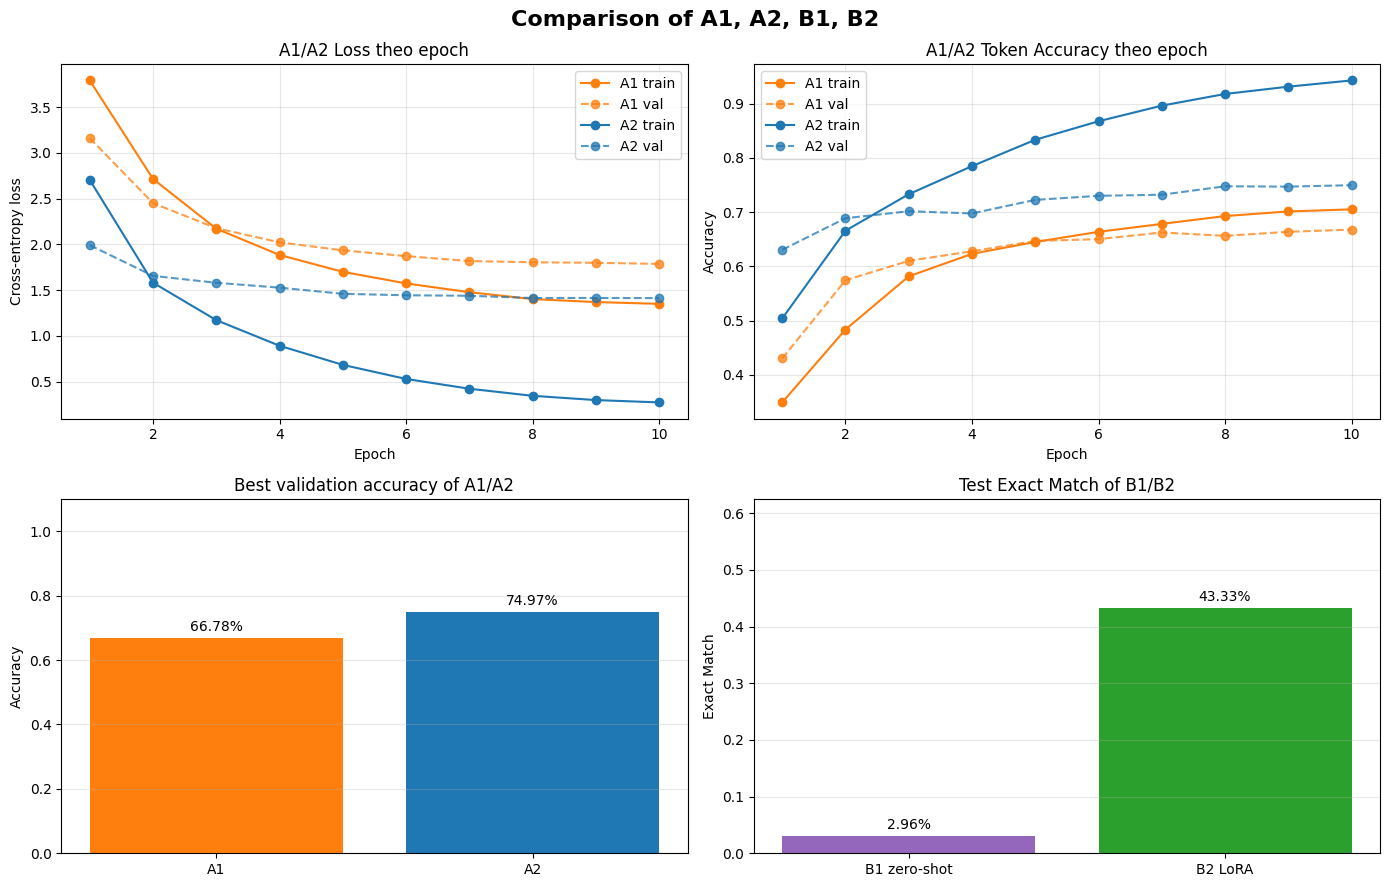

Summary
A1 best val acc: 0.6678, best val loss: 1.7882
A2 best val acc: 0.7497, best val loss: 1.4140
B1 exact match: 0.0296 / count=270
B2 exact match: 0.4333 / count=270


In [6]:
def safe_load_json(path: Path, default=None):
    if not path.exists():
        print(f"Missing file: {path}")
        return default
    return json.loads(path.read_text(encoding="utf-8"))


def summarize_a_history(history: Dict[str, List[float]]) -> Dict[str, float]:
    if not history:
        return {"best_val_loss": 0.0, "best_val_accuracy": 0.0}
    val_loss = history.get("val_loss", [])
    val_acc = history.get("val_accuracy", [])
    best_idx = min(range(len(val_loss)), key=lambda i: val_loss[i]) if val_loss else -1
    return {
        "best_val_loss": val_loss[best_idx] if best_idx >= 0 else 0.0,
        "best_val_accuracy": val_acc[best_idx] if best_idx >= 0 and val_acc else 0.0,
    }


def plot_four_model_comparison() -> None:
    """Plot training curves for A1/A2 and final metrics for A1/A2/B1/B2."""
    import matplotlib.pyplot as plt

    a1_history = safe_load_json(CHECKPOINT_DIR / "history_a1.json", {})
    a2_history = safe_load_json(CHECKPOINT_DIR / "history_a2.json", {})
    b1_metrics = safe_load_json(RESULT_DIR / "metrics_b1.json", {})
    b2_metrics = safe_load_json(RESULT_DIR / "metrics_b2_safe.json", {})

    a1_summary = summarize_a_history(a1_history)
    a2_summary = summarize_a_history(a2_history)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Comparison of A1, A2, B1, B2", fontsize=16, fontweight="bold")

    for label, history, color in [("A1", a1_history, "tab:orange"), ("A2", a2_history, "tab:blue")]:
        if not history:
            continue
        epochs = history.get("epoch") or list(range(1, len(history.get("train_loss", [])) + 1))
        axes[0, 0].plot(epochs, history.get("train_loss", []), marker="o", color=color, label=f"{label} train")
        axes[0, 0].plot(epochs, history.get("val_loss", []), marker="o", linestyle="--", color=color, alpha=0.75, label=f"{label} val")
        axes[0, 1].plot(epochs, history.get("train_accuracy", []), marker="o", color=color, label=f"{label} train")
        axes[0, 1].plot(epochs, history.get("val_accuracy", []), marker="o", linestyle="--", color=color, alpha=0.75, label=f"{label} val")

    axes[0, 0].set_title("A1/A2 Loss theo epoch")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Cross-entropy loss")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].set_title("A1/A2 Token Accuracy theo epoch")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    models_a = ["A1", "A2"]
    val_acc = [a1_summary["best_val_accuracy"], a2_summary["best_val_accuracy"]]
    bars = axes[1, 0].bar(models_a, val_acc, color=["tab:orange", "tab:blue"])
    axes[1, 0].set_title("Best validation accuracy of A1/A2")
    axes[1, 0].set_ylim(0, max(val_acc + [1.0]) * 1.1)
    axes[1, 0].set_ylabel("Accuracy")
    axes[1, 0].grid(True, axis="y", alpha=0.3)
    axes[1, 0].bar_label(bars, labels=[f"{v:.2%}" for v in val_acc], padding=3)

    models_b = ["B1 zero-shot", "B2 LoRA"]
    exact_match = [b1_metrics.get("exact_match", 0.0), b2_metrics.get("exact_match", 0.0)]
    bars = axes[1, 1].bar(models_b, exact_match, color=["tab:purple", "tab:green"])
    axes[1, 1].set_title("Test Exact Match of B1/B2")
    axes[1, 1].set_ylim(0, max(exact_match + [0.5]) * 1.25)
    axes[1, 1].set_ylabel("Exact Match")
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    axes[1, 1].bar_label(bars, labels=[f"{v:.2%}" for v in exact_match], padding=3)

    plt.tight_layout()
    plt.show()

    print("Summary")
    print(f"A1 best val acc: {a1_summary['best_val_accuracy']:.4f}, best val loss: {a1_summary['best_val_loss']:.4f}")
    print(f"A2 best val acc: {a2_summary['best_val_accuracy']:.4f}, best val loss: {a2_summary['best_val_loss']:.4f}")
    print(f"B1 exact match: {b1_metrics.get('exact_match', 0.0):.4f} / count={b1_metrics.get('count', 0)}")
    print(f"B2 exact match: {b2_metrics.get('exact_match', 0.0):.4f} / count={b2_metrics.get('count', 0)}")


plot_four_model_comparison()


## 5. Evaluation Metrics

Sinh dự đoán trên test set và tính metric cơ bản. Các metric mở rộng như ROUGE/METEOR/BERTScore có thể thêm ở báo cáo hoặc chạy bằng thư viện ngoài.


In [ ]:
def normalize_answer(text: Any) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[\.,;:!?]", "", text)
    return text


def decode_ids_with_vocab(ids, vocab) -> str:
    return vocab.decode([int(idx) for idx in ids])


def generate_predictions(model, loader, max_length: int = 12) -> Tuple[List[str], List[str]]:
    model.eval()
    predictions, references = [], []
    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            question_ids = batch["question_ids"].to(DEVICE)
            question_lengths = batch["question_lengths"].to(DEVICE)
            generated = model.generate(images, question_ids, question_lengths, max_length=max_length)
            predictions.extend(decode_ids_with_vocab(row.cpu().tolist(), answer_vocab) for row in generated)
            references.extend(batch["raw_answers"])
    return predictions, references


def exact_match_accuracy(predictions: Sequence[str], references: Sequence[str]) -> float:
    matches = [normalize_answer(pred) == normalize_answer(ref) for pred, ref in zip(predictions, references)]
    return sum(matches) / max(len(matches), 1)


def preview_predictions(predictions: Sequence[str], references: Sequence[str], limit: int = 10) -> None:
    for pred, ref in list(zip(predictions, references))[:limit]:
        print(f"PRED: {pred}\nREF : {ref}\n")

# Ví dụ sau khi load/train model_a2:
# preds_a2, refs = generate_predictions(model_a2, test_loader)
# print("A2 Exact Match:", exact_match_accuracy(preds_a2, refs))
# preview_predictions(preds_a2, refs)


## 6. B1/B2: Multimodal Pretrained

Phần B dùng Qwen2-VL:
- **B1**: zero-shot, không train, chỉ inference trên test set.
- **B2**: LoRA/QLoRA fine-tune trên train set, phù hợp Colab T4 hơn full fine-tune.

Kết quả được lưu vào `results/`, adapter B2 lưu vào `checkpoints/b2_qwen_lora/`.


In [ ]:
# Chạy cell cài đặt này trên Colab trước khi chạy B1/B2.
# Nếu package đã có sẵn, có thể bỏ qua.
# !pip install -q "transformers>=4.45.0" accelerate peft bitsandbytes qwen-vl-utils

RESULT_DIR = PROJECT_ROOT / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

B_MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"
B2_ADAPTER_DIR = CHECKPOINT_DIR / "b2_qwen_lora_safe"
B_MAX_NEW_TOKENS = 10

print("B model:", B_MODEL_NAME)
print("B2 adapter dir:", B2_ADAPTER_DIR)


In [ ]:
def build_qwen_messages(image_name: str, question: str, answer: Optional[str] = None) -> List[Dict]:
    image_path = IMAGE_DIR / image_name
    user_text = (
        "Bạn là hệ thống hỏi đáp ảnh biển báo giao thông Việt Nam. "
        "Trả lời tiếng Việt thật ngắn gọn, không quá 10 từ. "
        f"Câu hỏi: {question}"
    )
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(image_path)},
                {"type": "text", "text": user_text},
            ],
        }
    ]
    if answer is not None:
        messages.append({"role": "assistant", "content": [{"type": "text", "text": answer}]})
    return messages


def load_qwen2vl_model(
    model_name: str = B_MODEL_NAME,
    use_4bit: bool = False,
    trainable: bool = False,
):
    from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration

    processor = AutoProcessor.from_pretrained(model_name)
    processor.tokenizer.padding_side = "right"

    quantization_config = None
    if use_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )

    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_name,
        device_map="auto",
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        quantization_config=quantization_config,
    )
    if not trainable:
        model.eval()
    return model, processor


def qwen_device(model) -> torch.device:
    return next(model.parameters()).device


@torch.no_grad()
def qwen_predict(model, processor, image_name: str, question: str, max_new_tokens: int = B_MAX_NEW_TOKENS) -> str:
    from qwen_vl_utils import process_vision_info

    messages = build_qwen_messages(image_name, question)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(qwen_device(model))

    generation_config = getattr(model, "generation_config", None)
    if generation_config is not None:
        generation_config.do_sample = False
        generation_config.temperature = None
        generation_config.top_p = None
        generation_config.top_k = None

    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]
    return processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()


def save_json_rows(path: Path, rows: Sequence[Dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(list(rows), ensure_ascii=False, indent=2), encoding="utf-8")


def metric_summary_from_rows(rows: Sequence[Dict]) -> Dict[str, float]:
    predictions = [row["prediction"] for row in rows]
    references = [row["reference"] for row in rows]
    return {"exact_match": exact_match_accuracy(predictions, references), "count": len(rows)}


## B1

In [ ]:
def run_b1_zero_shot(limit: Optional[int] = None) -> Tuple[List[Dict], Dict[str, float]]:
    model_b1, processor_b1 = load_qwen2vl_model(use_4bit=False, trainable=False)
    records = test_records[:limit] if limit else test_records
    rows = []
    iterator = tqdm(records, desc="B1 zero-shot") if tqdm else records

    for row in iterator:
        pred = qwen_predict(model_b1, processor_b1, row["image"], row["question"])
        rows.append(
            {
                "image": row["image"],
                "question": row["question"],
                "reference": row["answer"],
                "prediction": pred,
            }
        )

    metrics = metric_summary_from_rows(rows)
    save_json_rows(RESULT_DIR / "predictions_b1.json", rows)
    (RESULT_DIR / "metrics_b1.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
    return rows, metrics


RUN_B1_ZERO_SHOT = False
B1_LIMIT = None  # Đặt 20 để test nhanh trước, None để chạy full test set.

if RUN_B1_ZERO_SHOT:
    b1_rows, metrics_b1 = run_b1_zero_shot(limit=B1_LIMIT)
    print(metrics_b1)
else:
    print("B1 chưa chạy. Đổi RUN_B1_ZERO_SHOT = True để evaluate zero-shot.")


## B2

In [ ]:
class QwenVQADataset(torch.utils.data.Dataset):
    def __init__(self, records: Sequence[Dict], max_samples: Optional[int] = None):
        self.records = list(records[:max_samples] if max_samples else records)

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> Dict:
        return self.records[index]


class QwenVQACollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, examples: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        from qwen_vl_utils import process_vision_info

        train_messages = [
            build_qwen_messages(ex["image"], ex["question"], ex["answer"])
            for ex in examples
        ]
        prompt_messages = [
            build_qwen_messages(ex["image"], ex["question"])
            for ex in examples
        ]

        texts = [
            self.processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=False)
            for msg in train_messages
        ]
        image_inputs, video_inputs = process_vision_info(train_messages)
        batch = self.processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        labels = batch["input_ids"].clone()
        pad_id = self.processor.tokenizer.pad_token_id
        labels[labels == pad_id] = -100

        # Mask prompt tokens so the loss focuses on the short answer.
        for row_idx, msg in enumerate(prompt_messages):
            prompt_text = self.processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
            prompt_image_inputs, prompt_video_inputs = process_vision_info(msg)
            prompt_inputs = self.processor(
                text=[prompt_text],
                images=prompt_image_inputs,
                videos=prompt_video_inputs,
                return_tensors="pt",
            )
            prompt_len = prompt_inputs["input_ids"].shape[1]
            labels[row_idx, :prompt_len] = -100

        batch["labels"] = labels
        return batch


def prepare_b2_lora_model():
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    model, processor = load_qwen2vl_model(use_4bit=True, trainable=True)
    model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        # Safer for T4: adapt attention only. MLP adapters + high LR caused repetitive outputs.
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model, processor


In [ ]:
def latest_trainer_checkpoint(output_dir: Path) -> Optional[str]:
    if not output_dir.exists():
        return None
    checkpoints = [p for p in output_dir.glob("checkpoint-*") if p.is_dir()]
    if not checkpoints:
        return None
    checkpoints.sort(key=lambda p: int(p.name.split("-")[-1]))
    return str(checkpoints[-1])


def save_trainer_log_history(trainer, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(trainer.state.log_history, ensure_ascii=False, indent=2), encoding="utf-8")


def ensure_b2_records_loaded() -> None:
    """Load dataset split variables when this B2 cell is run independently."""
    global train_records, val_records, test_records
    missing = [name for name in ("train_records", "val_records", "test_records") if name not in globals()]
    if not missing:
        return

    def _load_split(split_name: str) -> List[Dict]:
        split_path = DATASET_DIR / f"{split_name}.json"
        if not split_path.exists():
            raise FileNotFoundError(f"Missing split file: {split_path}")
        return json.loads(split_path.read_text(encoding="utf-8"))

    train_records = _load_split("train")
    val_records = _load_split("val")
    test_records = _load_split("test")
    print(
        "Loaded dataset splits for B2:",
        f"train={len(train_records)}, val={len(val_records)}, test={len(test_records)}",
    )


def train_b2_lora(
    train_limit: Optional[int] = None,
    val_limit: Optional[int] = 64,
    epochs: int = 1,
    resume: bool = True,
):
    from transformers import Trainer, TrainingArguments

    ensure_b2_records_loaded()
    model_b2, processor_b2 = prepare_b2_lora_model()
    train_dataset_b2 = QwenVQADataset(train_records, max_samples=train_limit)
    val_dataset_b2 = QwenVQADataset(val_records, max_samples=val_limit)
    collator = QwenVQACollator(processor_b2)

    import inspect
    training_args_kwargs = dict(
        output_dir=str(CHECKPOINT_DIR / "b2_qwen_runs_safe"),
        num_train_epochs=epochs,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=8,
        learning_rate=5e-5,
        fp16=torch.cuda.is_available(),
        logging_steps=20,
        save_steps=200,
        save_total_limit=2,
        eval_steps=200,
        remove_unused_columns=False,
        report_to="none",
        optim="paged_adamw_8bit",
    )
    if "eval_strategy" in inspect.signature(TrainingArguments).parameters:
        training_args_kwargs["eval_strategy"] = "steps"
    else:
        training_args_kwargs["evaluation_strategy"] = "steps"

    args = TrainingArguments(**training_args_kwargs)
    run_output_dir = Path(training_args_kwargs["output_dir"])
    resume_checkpoint = latest_trainer_checkpoint(run_output_dir) if resume else None
    if resume_checkpoint:
        print("Resuming B2 Trainer from:", resume_checkpoint)

    trainer = Trainer(
        model=model_b2,
        args=args,
        train_dataset=train_dataset_b2,
        eval_dataset=val_dataset_b2,
        data_collator=collator,
    )
    trainer.train(resume_from_checkpoint=resume_checkpoint)
    save_trainer_log_history(trainer, RESULT_DIR / "history_b2_trainer.json")
    model_b2.save_pretrained(B2_ADAPTER_DIR)
    processor_b2.save_pretrained(B2_ADAPTER_DIR)
    return model_b2, processor_b2


def load_b2_lora_for_inference(adapter_dir: Path = B2_ADAPTER_DIR):
    from peft import PeftModel

    if not adapter_dir.exists():
        fallback = latest_trainer_checkpoint(CHECKPOINT_DIR / "b2_qwen_runs_safe")
        if fallback is None:
            raise FileNotFoundError(f"Kh?ng t?m th?y B2 adapter: {adapter_dir}")
        print("Final adapter chưa có, fallback sang Trainer checkpoint:", fallback)
        adapter_dir = Path(fallback)

    base_model, processor = load_qwen2vl_model(use_4bit=True, trainable=False)
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()
    return model, processor


def run_b2_evaluation(model_b2, processor_b2, limit: Optional[int] = None) -> Tuple[List[Dict], Dict[str, float]]:
    ensure_b2_records_loaded()
    records = test_records[:limit] if limit else test_records
    rows = []
    iterator = tqdm(records, desc="B2 fine-tuned") if tqdm else records
    for row in iterator:
        pred = qwen_predict(model_b2, processor_b2, row["image"], row["question"])
        rows.append(
            {
                "image": row["image"],
                "question": row["question"],
                "reference": row["answer"],
                "prediction": pred,
            }
        )
    metrics = metric_summary_from_rows(rows)
    save_json_rows(RESULT_DIR / "predictions_b2_safe.json", rows)
    (RESULT_DIR / "metrics_b2_safe.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
    return rows, metrics


def inspect_b2_predictions(path: Path = RESULT_DIR / "predictions_b2_safe.json", limit: int = 8) -> None:
    rows = json.loads(path.read_text(encoding="utf-8"))
    colon_count = sum(1 for row in rows if ":" in row["prediction"])
    print("rows:", len(rows), "colon_outputs:", colon_count)
    for row in rows[:limit]:
        print("\nQ :", row["question"])
        print("GT:", row["reference"])
        print("B2:", row["prediction"])


RUN_B2_LORA_TRAIN = False
RUN_B2_EVAL = False
B2_TRAIN_LIMIT = None  # Đặt 512 để smoke test, None để dùng toàn bộ train set.
B2_EPOCHS = 1  # Chạy 1 epoch trước; nếu output ổn nhưng metric thấp thì tăng lên 2.
B2_EVAL_LIMIT = None

if RUN_B2_LORA_TRAIN:
    model_b2, processor_b2 = train_b2_lora(train_limit=B2_TRAIN_LIMIT, epochs=B2_EPOCHS, resume=True)
else:
    print("B2 chưa train. Đổi RUN_B2_LORA_TRAIN = True để fine-tune LoRA.")

if RUN_B2_EVAL:
    if "model_b2" not in globals() or "processor_b2" not in globals():
        model_b2, processor_b2 = load_b2_lora_for_inference()
    b2_rows, metrics_b2 = run_b2_evaluation(model_b2, processor_b2, limit=B2_EVAL_LIMIT)
    print(metrics_b2)
else:
    print("B2 chưa evaluate. Đổi RUN_B2_EVAL = True sau khi có adapter.")


In [ ]:
!pip -q install gradio
import gradio as gr
from pathlib import Path
from PIL import Image
from contextlib import nullcontext

def qwen_predict_pil(image, question, model, processor, temp_path: Path):
    from qwen_vl_utils import process_vision_info

    if image is None:
        return "Vui lòng upload ảnh."
    if not question.strip():
        return "Vui lòng nhập câu hỏi."

    temp_path = Path(temp_path)
    image = image.convert("RGB")
    image.save(temp_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(temp_path)},
                {"type": "text", "text": f"Trả lời ngắn gọn bằng tiếng Việt. Câu hỏi: {question}"},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(qwen_device(model))

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
        )

    generated_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    answer = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    return answer


def ensure_b2_loaded_for_demo():
    global model_b2, processor_b2
    if "model_b2" not in globals() or "processor_b2" not in globals():
        model_b2, processor_b2 = load_b2_lora_for_inference()
    return model_b2, processor_b2


def qwen_predict_b2_pil(image, question):
    model, processor = ensure_b2_loaded_for_demo()
    return qwen_predict_pil(image, question, model, processor, Path("/content/realtime_b2_image.png"))


def qwen_predict_b1_pil(image, question):
    model, processor = ensure_b2_loaded_for_demo()
    adapter_context = model.disable_adapter() if hasattr(model, "disable_adapter") else nullcontext()
    with adapter_context:
        return qwen_predict_pil(image, question, model, processor, Path("/content/realtime_b1_image.png"))


def compare_b1_b2(image, question):
    return qwen_predict_b1_pil(image, question), qwen_predict_b2_pil(image, question)


In [ ]:
gr.close_all()

demo = gr.Interface(
    fn=compare_b1_b2,
    inputs=[
        gr.Image(type="pil", label="Upload ảnh biển báo"),
        gr.Textbox(label="Câu hỏi", value="Biển báo này có ý nghĩa gì?"),
    ],
    outputs=[
        gr.Textbox(label="B1 zero-shot realtime"),
        gr.Textbox(label="B2 fine-tuned LoRA realtime"),
    ],
    title="So sánh B1 vs B2 realtime",
    description="B1 dùng Qwen2-VL base bằng cách tạm tắt LoRA adapter; B2 dùng cùng base model với LoRA đã fine-tune.",
)

demo.queue(default_concurrency_limit=1).launch(share=True, debug=False, show_error=True)


## 7. Bài 2: Explainable VQA

Bài 2 vẫn dùng VQA nhưng mở rộng output: câu trả lời, giải thích ngắn, khuyến nghị hành động và mức tin cậy heuristic.


In [ ]:
def explainable_vqa_response(answer: str, question: str) -> Dict[str, Any]:
    answer_norm = normalize_answer(answer)
    if "cấm" in answer_norm:
        recommendation = "Không thực hiện hành vi bị cấm trên biển."
    elif "nguy hiểm" in answer_norm or "cảnh báo" in answer_norm:
        recommendation = "Giảm tốc độ và chú ý quan sát."
    elif "hiệu lệnh" in answer_norm or "chỉ dẫn" in answer_norm:
        recommendation = "Đi theo hướng dẫn thể hiện trên biển."
    else:
        recommendation = "Quan sát thêm ngữ cảnh trước khi quyết định."

    explanation = "Model VQA suy luận từ đặc trưng ảnh và nội dung câu hỏi."
    confidence = 0.75 if answer.strip() else 0.35
    return {
        "question": question,
        "answer": answer,
        "explanation": explanation,
        "recommendation": recommendation,
        "confidence": confidence,
    }

# Ví dụ:
# explainable_vqa_response("Biển báo hiệu lệnh quay đầu xe.", "Biển báo này có ý nghĩa gì?")
